In [10]:
import sys
import os
from tqdm import tqdm
from libs.danbooru_client import create_danbooru_client
from libs.character_search import (
    calculate_average_tag_frequency,
    calculate_gender_frequencies,
)
from dataclasses import dataclass


@dataclass
class TagData:
    tag: str
    female_frequency: float
    male_frequency: float
    gender: str
    post_count: int


client = create_danbooru_client()

In [11]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置全局字体为 Noto Sans CJK SC（简体中文）
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]  # 使用 Noto Sans CJK SC
rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 读取女性数据
tags = []
female_data = [[], [], []]
with open("outputs/arknights_female_characters.csv", "r", encoding="utf-8") as f:
    next(f)  # 跳过标题行
    for line in f:
        split = line.strip().split(",")
        tag = TagData(
            tag=split[0],
            male_frequency=float(split[1]),
            female_frequency=float(split[2]),
            gender="Female",
            post_count=int(split[3]),
        )
        tags.append(tag)
        female_data[0].append(tag.male_frequency)
        female_data[1].append(tag.female_frequency)
        female_data[2].append(tag.post_count)

# 读取男性数据
male_data = [[], [], []]
with open("outputs/arknights_male_characters.csv", "r", encoding="utf-8") as f:
    next(f)  # 跳过标题行
    for line in f:
        split = line.strip().split(",")
        tag = TagData(
            tag=split[0],
            male_frequency=float(split[1]),
            female_frequency=float(split[2]),
            gender="Male",
            post_count=int(split[3]),
        )
        tags.append(tag)
        male_data[0].append(tag.male_frequency)
        male_data[1].append(tag.female_frequency)
        male_data[2].append(tag.post_count)

# 处理未知性别的标签
unknown_gender_data = [[], [], []]
with open(
    "outputs/arknights_unknown_gender_characters.csv", "r", encoding="utf-8"
) as f:
    next(f)  # 跳过标题行
    for line in f:
        split = line.strip().split(",")
        tag = TagData(
            tag=split[0],
            male_frequency=float(split[1]),
            female_frequency=float(split[2]),
            gender="Unknown",
            post_count=int(split[3]),
        )
        tags.append(tag)
        unknown_gender_data[0].append(tag.male_frequency)
        unknown_gender_data[1].append(tag.female_frequency)
        unknown_gender_data[2].append(tag.post_count)

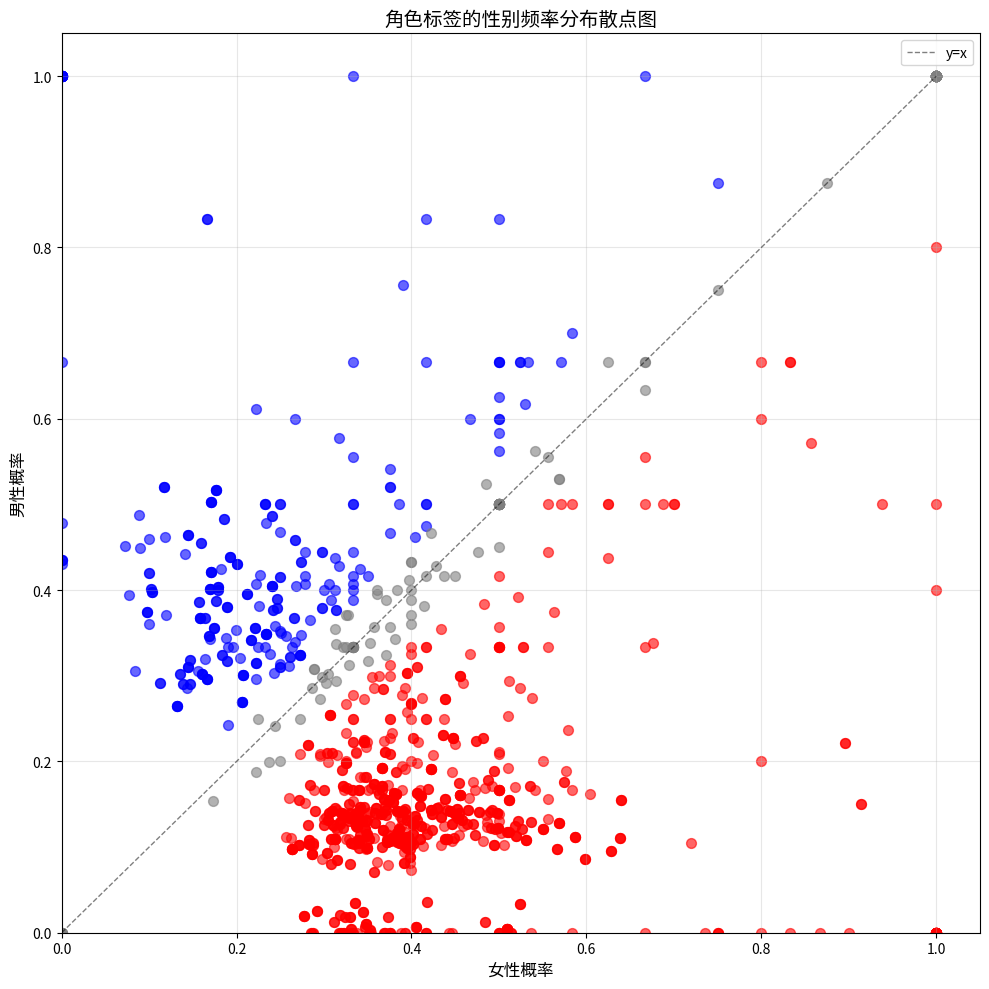

In [12]:
# 绘制散点图
plt.figure(figsize=(10, 10))
plt.scatter(female_data[1], female_data[0], alpha=0.6, s=50, c="red")
plt.scatter(male_data[1], male_data[0], alpha=0.6, s=50, c="blue")
plt.scatter(
    unknown_gender_data[1],
    unknown_gender_data[0],
    alpha=0.6,
    s=50,
    c="gray",
)

# 设置坐标轴标签和标题（现在可以正确显示中文）
plt.xlabel("女性概率", fontsize=12)
plt.ylabel("男性概率", fontsize=12)
plt.title("角色标签的性别频率分布散点图", fontsize=14)

plt.grid(True, alpha=0.3)
max_freq = max(
    max(female_data[1]) if female_data[1] else 0,
    max(female_data[0]) if female_data[0] else 0,
)
if max_freq > 0:
    plt.plot([0, max_freq], [0, max_freq], "k--", alpha=0.5, linewidth=1, label="y=x")
    plt.legend()
    plt.xlim(0, max_freq * 1.05)
    plt.ylim(0, max_freq * 1.05)


plt.tight_layout()
plt.show()

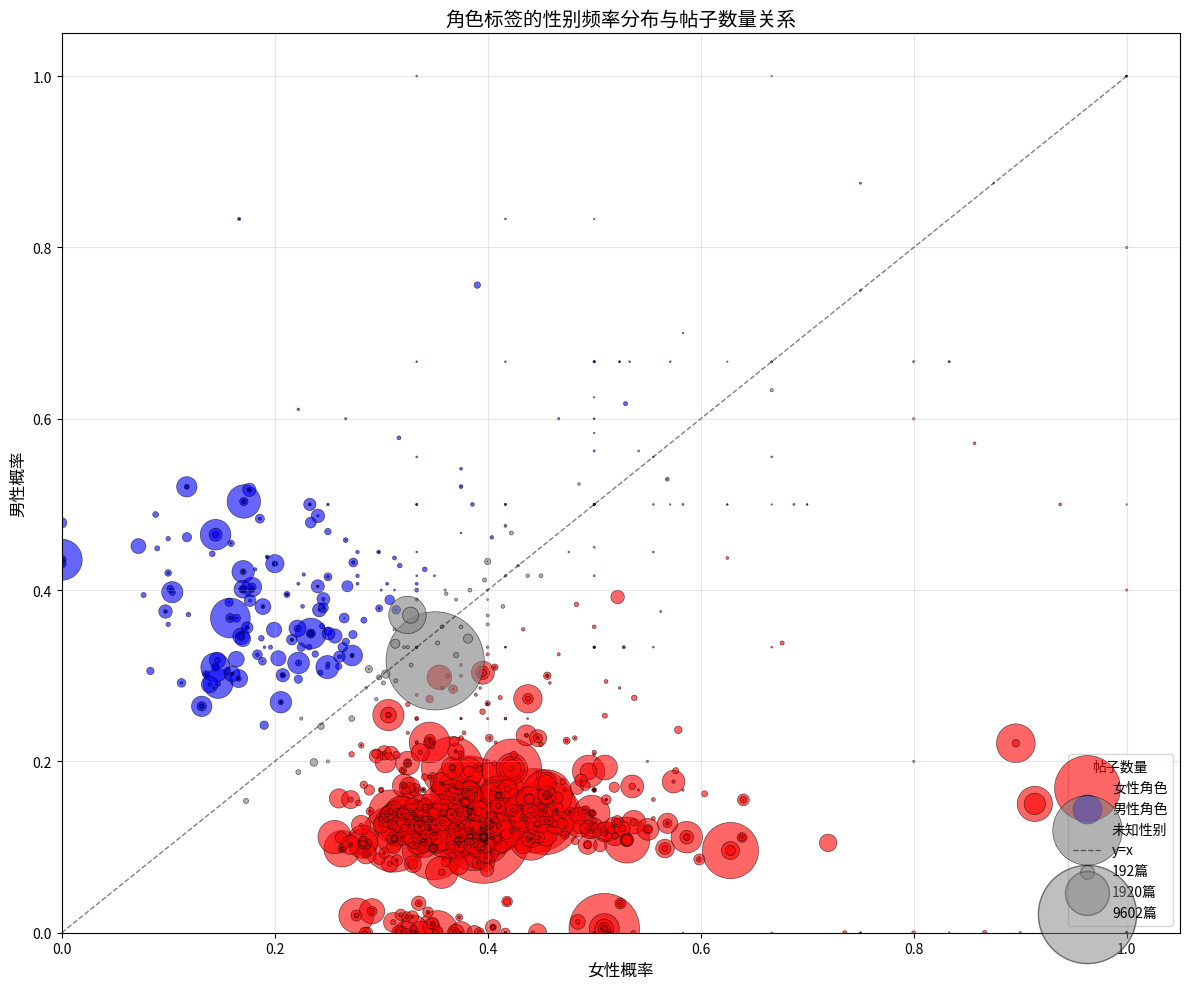

In [13]:
# 绘制气泡图
plt.figure(figsize=(12, 10))

# 计算气泡大小的缩放因子，使气泡大小适中
max_post_count = max(
    max(female_data[2]) if female_data[2] else 0,
    max(male_data[2]) if male_data[2] else 0,
    max(unknown_gender_data[2]) if unknown_gender_data[2] else 0
)
size_scale = 5000 / max_post_count if max_post_count > 0 else 1

# 绘制女性角色数据点（红色气泡）
plt.scatter(
    female_data[1], 
    female_data[0], 
    s=[size * size_scale for size in female_data[2]], 
    alpha=0.6, 
    c="red",
    edgecolors='black',
    linewidths=0.5,
    label="女性角色"
)

# 绘制男性角色数据点（蓝色气泡）
plt.scatter(
    male_data[1], 
    male_data[0], 
    s=[size * size_scale for size in male_data[2]], 
    alpha=0.6, 
    c="blue",
    edgecolors='black',
    linewidths=0.5,
    label="男性角色"
)

# 绘制未知性别角色数据点（灰色气泡）
plt.scatter(
    unknown_gender_data[1], 
    unknown_gender_data[0], 
    s=[size * size_scale for size in unknown_gender_data[2]], 
    alpha=0.6, 
    c="gray",
    edgecolors='black',
    linewidths=0.5,
    label="未知性别"
)

# 设置坐标轴标签和标题
plt.xlabel("女性概率", fontsize=12)
plt.ylabel("男性概率", fontsize=12)
plt.title("角色标签的性别频率分布与帖子数量关系", fontsize=14)

# 添加参考线
max_freq = max(
    max(female_data[1]) if female_data[1] else 0,
    max(female_data[0]) if female_data[0] else 0,
)
if max_freq > 0:
    plt.plot([0, max_freq], [0, max_freq], "k--", alpha=0.5, linewidth=1, label="y=x")
    plt.xlim(0, max_freq * 1.05)
    plt.ylim(0, max_freq * 1.05)

# 添加图例
plt.legend(title="角色性别", loc="upper right")

# 添加气泡大小说明
for size in [100, 1000, 5000]:
    plt.scatter([], [], s=size, c='gray', alpha=0.5, edgecolors='black', 
                label=f'{int(size/size_scale)}篇')
plt.legend(title="帖子数量", loc="lower right", bbox_to_anchor=(1, 0))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 找出性别差异小于0.05的标签
similar_tags = [
    tag for tag in tags if abs(tag.female_frequency - tag.male_frequency) < 0.05
]
# 打印性别差异小于0.05的标签
print("性别差异小于0.05的标签:")
# 按照相差绝对值从大到小排序
similar_tags.sort(
    key=lambda x: abs(x.female_frequency - x.male_frequency), reverse=True
)

for tag in similar_tags:
    print(
        f"{tag.tag}: 女性频率={tag.female_frequency}, 男性频率={tag.male_frequency}, 相差={tag.female_frequency-tag.male_frequency}, 是否男性={tag.gender}, 总帖子数={tag.post_count}"
    )
print(f"差异小于0.05的标签数: {len(similar_tags)}")